# Загрузка библиотек

In [58]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import sklearn.cluster as cluster
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Загрузка данных

In [61]:
data = pd.read_csv("wine-clustering.csv")

data.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


# Определение кол-ва кластеров

## Стандартизация данных

In [4]:
scaler = StandardScaler()

standarded_data = scaler.fit_transform(data) # стандартизируем данные

In [5]:
standarded_data

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]])

Модели кластеризации чувствительны к распределению данных, то есть признак с большими значениями будет больше влиять на определение кластеров, чем признак с меньшими значениями. Поэтому стандартизируем все данные.

## Приоритет нужным признакам

In [7]:
standarded_data[:, 0] = standarded_data[:, 0] * 2

Увеличиваем значения признака Alcohol в 2 раза, чтобы кластеры были осмысленные (то есть сегментировались по содержанию алкоголя, в первую очередь, и по другим признакам, во вторую очередь).

## Определение кол-ва кластеров через метод локтя

In [8]:
K = range(1,12)
wss = []
for k in K:
    kmeans=cluster.KMeans(n_clusters=k,init="k-means++", random_state=42)
    kmeans=kmeans.fit(standarded_data)
    wss_iter = kmeans.inertia_
    wss.append(wss_iter)

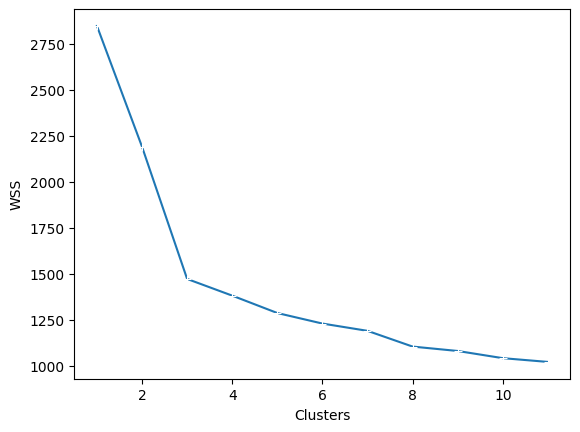

In [9]:
mycenters = pd.DataFrame({'Clusters' : K, 'WSS' : wss})

sns.lineplot(x = 'Clusters', y = 'WSS', data = mycenters, marker="+")
plt.show()

Метод локтя представляет собой эффективный подход к определению оптимального количества кластеров при использовании алгоритмов кластеризации, таких как K-means. Его применение основано на анализе изменения внутрикластерной суммы квадратов расстояний (WCSS) при последовательном увеличении числа кластеров.

Суть метода заключается в следующем: мы последовательно вычисляем значение WCSS для различного количества кластеров (обычно в диапазоне от 1 до 10) и строим соответствующий график зависимости. На этом графике мы ищем характерный "изгиб" или "локоть" - точку, после которой добавление новых кластеров перестает существенно уменьшать общую сумму квадратов расстояний внутри кластеров.

В нашем конкретном случае анализ показал, что оптимальным является выбор <b>3</b> кластеров.

## Определение кол-ва кластеров через оценку силуета

In [10]:
for k in range(2, 12):
    model = cluster.KMeans(n_clusters=k,init="k-means++", random_state=42)
    model.fit(standarded_data)
    pred = model.predict(standarded_data)
    score = silhouette_score(standarded_data, pred)
    print('Silhouette Score for k = {}: {:<.3f}'.format(k, score))

Silhouette Score for k = 2: 0.228
Silhouette Score for k = 3: 0.323
Silhouette Score for k = 4: 0.256
Silhouette Score for k = 5: 0.206
Silhouette Score for k = 6: 0.166
Silhouette Score for k = 7: 0.155
Silhouette Score for k = 8: 0.143
Silhouette Score for k = 9: 0.123
Silhouette Score for k = 10: 0.118
Silhouette Score for k = 11: 0.110



Метод Silhouette Score представляет собой более совершенный подход к оценке качества кластеризации по сравнению с методом локтя. В то время как метод локтя фокусируется исключительно на минимизации внутрикластерных расстояний (WCSS), Silhouette Score учитывает комплексную структуру данных, оценивая одновременно два ключевых аспекта: компактность кластеров (насколько близки точки внутри одного кластера) и степень их разделимости (насколько хорошо кластеры отделены друг от друга).

Принцип расчета Silhouette Score основан на сравнении двух показателей для каждой точки данных. Первый показатель (a(i)) отражает среднее расстояние от текущей точки до всех других точек в том же кластере - это мера компактности кластера. Второй показатель (b(i)) представляет собой минимальное среднее расстояние от данной точки до точек в любом другом кластере - это мера разделимости кластеров. На основе этих значений для каждой точки вычисляется индивидуальный коэффициент силуэта по специальной формуле, который затем усредняется по всем точкам набора данных.

Особенность Silhouette Score заключается в том, что он принимает значения в диапазоне от -1 до 1. При этом значение, близкое к 1, указывает на отличную кластеризацию, где кластеры четко выделены и хорошо разделены. Значения около 0 свидетельствуют о перекрывающихся кластерах, а отрицательные значения сигнализируют о потенциально ошибочной кластеризации, когда многие точки могут быть отнесены к неверным кластерам.


В нашем конкретном случае анализ с использованием Silhouette Score подтвердил оптимальность выбора <b>3</b> кластеров.

## Отбор важных признаков

In [53]:
kmeans=cluster.KMeans(n_clusters=3,init="k-means++", random_state=42)

kmeans.fit(standarded_data)

clusters = kmeans.predict(standarded_data)

In [63]:
X_train, X_test, y_train, y_test = train_test_split(standarded_data, clusters, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

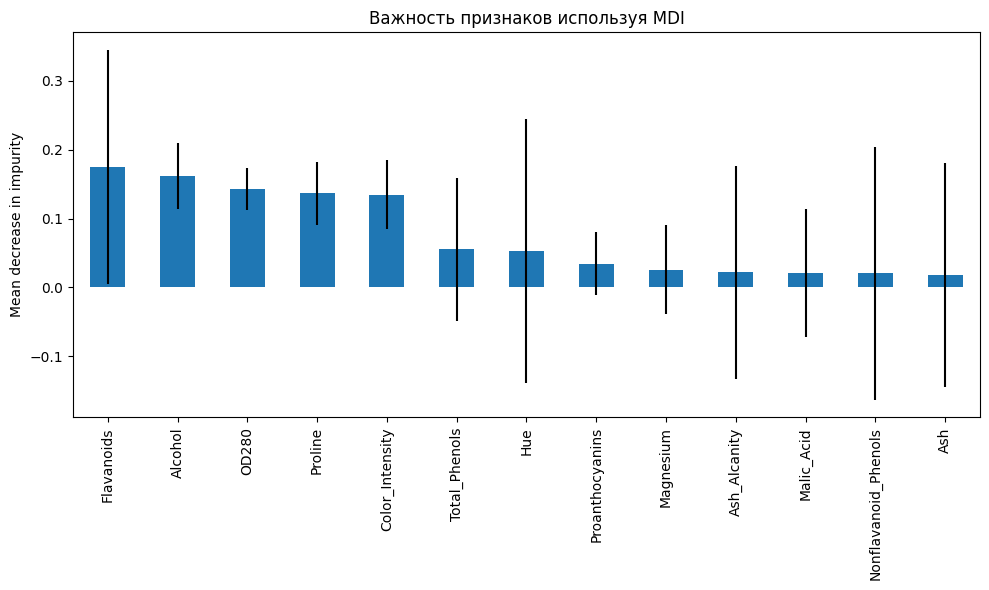

In [64]:
importances = clf.feature_importances_

std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)

forest_importances = pd.Series(importances, index=data.columns).sort_values(ascending=False)


fig, ax = plt.subplots(figsize=(10, 6))
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Важность признаков используя MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

In [65]:
X = data[["Flavanoids", "Alcohol", "OD280", "Proline", "Color_Intensity"]]

scaler = StandardScaler()

scaled_X = scaler.fit_transform(X) # стандартизируем данные

Random Forest для отбора признаков перед кластеризацией — это мощный и универсальный подход. Его главные преимущества: работает с любыми типами данных без предварительной нормализации, устойчив к шуму и переобучению благодаря ансамблевому принципу, а также наглядно показывает важность каждого признака через метрику MDI (Mean Decrease in Impurity). Ваш код эффективно реализует этот подход — сначала вычисляется средняя важность признаков по всем деревьям, затем оценивается разброс значений для отсева нестабильных признаков. Это особенно полезно, когда нужно: 1) выявить ключевые факторы, влияющие на структуру данных; 2) удалить избыточные или шумовые признаки; 3) сделать кластеры более интерпретируемыми. При этом метод не требует меток классов и автоматически учитывает взаимосвязи между переменными. Для лучших результатов можно дополнительно использовать permutation importance или ограничить глубину деревьев.

В нашем случае важными признаками стали: Flavanoids, Alcohol, OD280, Proline, Color_Intensity.

## Уменьшение размерности (если не отбор признаков)

In [11]:
pca = PCA(n_components=7)

X_pca = pca.fit_transform(standarded_data)

print(sum(pca.explained_variance_ratio_))

0.9034274664503523


In [12]:
pickle.dump(pca, open("PCA.sav", 'wb'))

Сжимаем кол-во признаков, чтобы избавиться от мультиколлениарности, упростить модель, уменьшить размерность данных. Для этого оставляем 7 компонент, так как сохраняется 90% вариативности.

## Приоритет нужным признакам

In [75]:
scaled_X[:, 1] = scaled_X[:, 1] * 2

Увеличиваем значения признака Alcohol в 2 раза, чтобы кластеры были осмысленные (то есть сегментировались по содержанию алкоголя, в первую очередь, и по другим признакам, во вторую очередь).

## Выбор лучшей модели

In [76]:
# Метрики для выбора модели
def get_clustering_metrics(clusters):
    print("Коэффициент силуета:", silhouette_score(scaled_X, clusters))
    print("Индекс Дэвиса-Боулдина:", davies_bouldin_score(scaled_X, clusters))

* Коэффициент силуета - описан раннее.

* Индекс Девида Боулдина - метрика для оценки качества кластеризации, которая измеряет среднее сходство между кластерами, где сходство рассчитывается как отношение внутрикластерной компактности к межкластерной разделимости. Чем меньше значение индекса, тем лучше кластеризация. В нашем случае поможет качественно оценить разделение на кластеры.

### KMeans

In [77]:
kmeans = cluster.KMeans(n_clusters=3, init="k-means++", random_state=42)
clusters = kmeans.fit_predict(scaled_X)

get_clustering_metrics(clusters)

Коэффициент силуета: 0.44872252118986516
Индекс Дэвиса-Боулдина: 0.8527730382985069


K-Means++ представляет собой улучшенную версию классического алгоритма K-Means, где начальные центроиды выбираются более осмысленно, что позволяет избежать проблем с плохой инициализацией. Этот метод особенно эффективен для данных, которые имеют сферическую или близкую к сферической форму кластеров, что часто наблюдается после применения PCA. Главное преимущество K-Means++ заключается в его вычислительной эффективности – алгоритм работает быстро даже на относительно больших наборах данных, что делает его популярным выбором для первоначального анализа. Однако важно учитывать, что K-Means++ предполагает, что все кластеры имеют примерно одинаковый размер и плотность, что может не соответствовать реальным данным. Кроме того, метод требует заранее заданного количества кластеров, что иногда представляет сложность, если истинная структура данных неизвестна.

### Agglomerative Clustering

In [78]:
agg_model = cluster.AgglomerativeClustering(
    n_clusters=3,          # Фиксируем 3 кластера
    linkage='ward'         # Оптимально для PCA-данных (минимизирует дисперсию)
)
clusters = agg_model.fit_predict(scaled_X)

get_clustering_metrics(clusters)

Коэффициент силуета: 0.42989951155036826
Индекс Дэвиса-Боулдина: 0.8882241831900938


Агломеративная кластеризация, или иерархическая кластеризация, строит дерево (дендрограмму), последовательно объединяя наиболее похожие пары кластеров. Этот метод особенно полезен, когда данные имеют явную иерархическую структуру или когда необходимо исследовать возможные уровни группировки без строгого задания числа кластеров заранее. Одним из ключевых преимуществ Agglomerative Clustering является его гибкость – можно выбирать различные метрики расстояния и методы связи (linkage), такие как 'ward', 'complete' или 'average', что позволяет адаптировать алгоритм под особенности данных. Однако этот метод существенно медленнее K-Means и плохо масштабируется на большие наборы данных из-за своей вычислительной сложности. Также он чувствителен к шуму и выбросам, которые могут сильно исказить структуру дендрограммы.

### Gaussian Mixture

In [79]:
gmm = GaussianMixture(n_components=3, random_state=42)

clusters = gmm.fit_predict(scaled_X)
get_clustering_metrics(clusters)

Коэффициент силуета: 0.4208028431316644
Индекс Дэвиса-Боулдина: 0.8827402353052456


GMM представляет собой вероятностный подход к кластеризации, предполагая, что данные генерируются смесью нескольких гауссовых распределений. В отличие от K-Means, GMM не требует, чтобы кластеры были сферическими и одинакового размера – они могут быть вытянутыми или иметь разную плотность, что делает этот метод более гибким для реальных данных. Важным преимуществом GMM является возможность получения вероятностных оценок принадлежности каждой точки к кластерам, что полезно для анализа нечетких случаев. Однако GMM требует больше вычислительных ресурсов, чем K-Means, и может быть чувствителен к начальной инициализации параметров. Кроме того, как и K-Means, он требует задания числа кластеров заранее, а его интерпретация может быть сложнее из-за вероятностной природы модели.

### Вывод
Лучшей моделью оказалась KMeans++. Её мы и сохраняем.

In [80]:
pickle.dump(kmeans, open("Clustering_Model.sav", 'wb'))

# Интерпритация кластеров

In [81]:
kmeans = pickle.load(open("Clustering_Model.sav", 'rb'))
clusters = kmeans.predict(scaled_X)

data["Cluster"] = clusters

## Распределение целевого признака по кластерам

In [82]:
fig = px.histogram(
    data,
    x="Cluster",
    title='Частота кластеров',
    color="Cluster",
    text_auto=True
)

fig.show()

In [87]:
fig = px.histogram(
    data,
    x="Alcohol",
    title='Распределение целевого признака по кластерам',
    color="Cluster",
    text_auto=True
)

fig.show()

In [88]:
fig = px.box(
    data,
    x="Cluster",
    y="Alcohol",
    title='Распределение целевого признака по кластерам',
    color="Cluster"
)

fig.show()

На гистрограмме и боксплоте видно, что средние значения и распределения по целевому признаку Alcohol отличаются. Следовательно, модель успешно справилась со своей задачей.

## Распределение сжатых признаков по кластерам

In [89]:
X = data.drop(columns=["Cluster"])

scaler = StandardScaler()

standarded_cluster_data = scaler.fit_transform(X)


pca = PCA(n_components=3)
 
reduced_X = pd.DataFrame(data=pca.fit_transform(standarded_cluster_data),columns=['PCA1','PCA2', 'PCA3'])

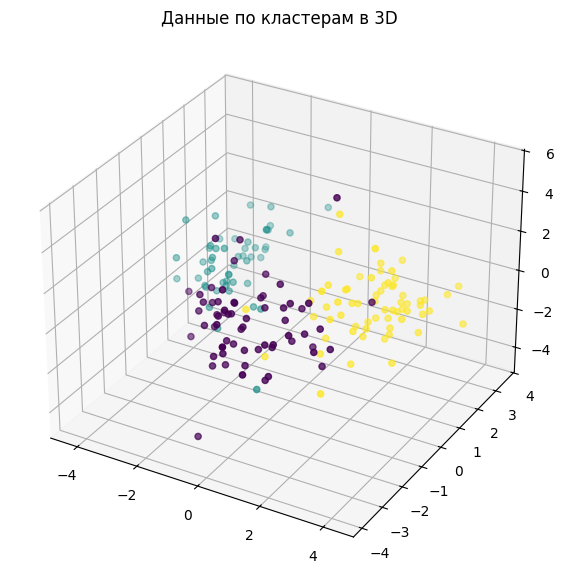

In [90]:
fig = plt.figure(figsize = (10, 7))
ax = plt.axes(projection ="3d")
 
# Creating plot
ax.scatter3D(reduced_X["PCA1"], reduced_X["PCA2"], reduced_X["PCA3"], c=kmeans.labels_)

plt.title("Данные по кластерам в 3D")

plt.show()

In [91]:
pca = PCA(n_components=2)
 
reduced_X = pd.DataFrame(data=pca.fit_transform(standarded_cluster_data),columns=['PCA1','PCA2'])

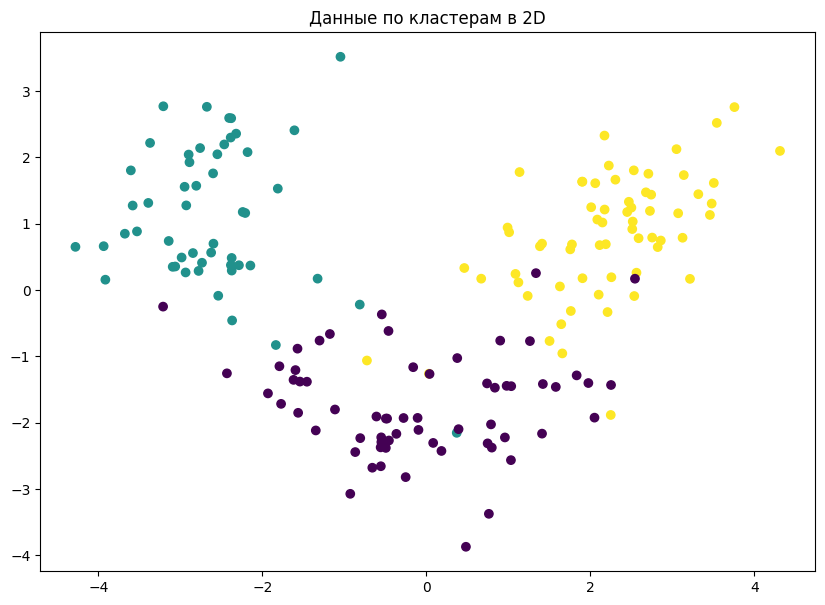

In [92]:
fig = plt.figure(figsize = (10, 7))
ax = plt.axes()
 
# Creating plot
ax.scatter(reduced_X["PCA1"], reduced_X["PCA2"], c=kmeans.labels_)

plt.title("Данные по кластерам в 2D")
plt.show()

Как можно увидеть на scatterplot (в 2D и 3D), сжатые признаки хорошо разделяются по кластерам. За исключением некоторых точек, которые внутри других кластеров.